# Config

In [7]:
import time

_timers = {}

def timer_start(name="default"):
    _timers[name] = time.perf_counter()

def timer_end(name="default"):
    dt = time.perf_counter() - _timers.pop(name)
    print(f"[{name}] {dt:.2f}s")
    return dt
timer_start()

In [3]:
# Cell 0 — CONFIG
#case
case_name = "206_copper_05b"
experiment = "Pipe_eval_01"

import json
from pathlib import Path
from pprint import pprint
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
# These two are the PARENT stage folders. Each recon's own frame set now lives in a
# beat-keyed subfolder of them, handed out by build_recon_requests as job["frames_dir"].
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")
restart =True




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project_root: /workspace/project
/workspace/project True
/workspace/project/Data/206_copper_05b/010_source
Case    : 206_copper_05b
Video   : log_#2022-0002295_body_worn_camera_2_v1.mp4
video fps: 29.970
total_frames 15744


In [4]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : True,
    "PROJECTION": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

#2d ANALYSIS - JUST GPS now!
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


# AI First Pass
## Gem, vid to text

In [10]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini_v04 import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")

uploading video
re_caching video
[gemini-diag] video duration 08:45, 1 windows for summary/transcript
00:00 - 00:30: The video begins with the camera inside a police vehicle, showing the perspective from the back seat. An officer is driving through a residential neighborhood.

00:30 - 01:00: The police vehicle continues driving through the neighborhood streets, turning corners as the officers navigate.

01:00 - 01:30: The officers continue driving, passing houses and parked cars along the street.

01:30 - 02:00: The vehicle continues its journey through the residential area, approaching the scene of the incident.

02:00 - 02:15: The police vehicle stops, and the officer wearing the body camera quickly exits the car and begins running toward the scene of an active incident.

02:15 - 02:30: The officer runs down the street, looking for his colleagues and assessing the situation as he approaches.

02:30 - 03:05: The officer reaches an injured colleague who is kneeling on the ground with a

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [11]:
repeat = True
if repeat == True:
    from Two2D.A_gemini_v04 import gemini_people
    people = gemini_people()
    print(json.dumps(people, indent=2))

{
  "people": [
    {
      "person_id": "person-A",
      "descriptor": "Injured police officer with glasses, wearing a blue shirt, seen driving and then kneeling on the ground",
      "appearances": [
        {
          "start_s": 0,
          "end_s": 121
        },
        {
          "start_s": 124,
          "end_s": 126
        },
        {
          "start_s": 147,
          "end_s": 193
        },
        {
          "start_s": 202,
          "end_s": 232
        }
      ]
    },
    {
      "person_id": "person-B",
      "descriptor": "Police officer sitting in the front passenger seat of the police car",
      "appearances": [
        {
          "start_s": 10,
          "end_s": 121
        }
      ]
    },
    {
      "person_id": "person-D",
      "descriptor": "Suspect lying on the ground, black male with dreadlocks, wearing black clothing and a blue cap",
      "appearances": [
        {
          "start_s": 144,
          "end_s": 184
        },
        {
          "s

In [12]:
#Transcript
# speech transcript: whisper words + pyannote speakers + audio events
if restart == False:
    from run_models.A_ASR_diarize import transcribe_and_diarize
    asr_transcript = transcribe_and_diarize()
    print(asr_transcript.read_text()[:2000])
else:
    print("cell disabled")


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[asr] extracting audio from log_#2022-0002295_body_worn_camera_2_v1.mp4
[asr] 34 speech regions, 3.6 min of speech
[asr] whisper large-v3 on cuda
[asr]   ...02:13
[asr]   ...07:50
[asr] 368 words (165 dropped as non-speech) -> 206_copper_05b_Pipe_eval_01_asr_words.json
[asr] reusing 206_copper_05b_Pipe_eval_01_audio16k.wav
[asr] diarizing with pyannote/speaker-diarization-3.1


/home/vscode/.local/lib/python3.11/site-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/pyannote/audio/models/blocks/pooling.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  std = sequences.std(dim=-1, correction=1)


[asr] 162 turns, 2 speakers
[asr] reusing 206_copper_05b_Pipe_eval_01_audio16k.wav


Loading weights: 100%|██████████| 203/203 [00:00<00:00, 9419.88it/s]

[asr] tagging audio events with ast-finetuned-audioset-10-10-0.4593


[asr] 15 audio events (6 vocal) -> 206_copper_05b_Pipe_eval_01_audio_events.json
[asr] 45 utterances + 15 events -> /workspace/project/Data/206_copper_05b/013_ASR_outputs/206_copper_05b_Pipe_eval_01_transcript_asr.txt
**02:13-02:14** [SPEAKER_00]: 10 -1, squad, 10 -1.

**02:16-02:18** [SPEAKER_00]: Which one? Where's this?

**02:18-02:27** [sound]: Clip-clop (0.54)

**02:23-02:26** [SPEAKER_00]: 690 Sagamon squad 690 Sagamon 10 -1

**02:27-02:27** [UNKNOWN]: 7

**02:27-02:31** [SPEAKER_01]: -6 -1 -boy Collins, 10 -1, shot fired, it's about a police arrest, police, 6 -9

**02:31-02:33** [UNKNOWN]: -1, 6 -9 -1, 7 -6

**02:33-02:34** [SPEAKER_01]: -1 -boy Collins, 10 -1.

**02:34-02:35** [SPEAKER_00]: I got you, bro. I got you.

**02:35-02:36** [SPEAKER_01]: Police, police,

**02:36-02:36** [UNKNOWN]: they're at

**02:36-02:39** [SPEAKER_01]: the police. Mano, mano, mano, mano, mano. He's running at us.

**02:41-02:45** [SPEAKER_00]: Hey, take me to University of Chicago Lake. Squad! Squa

/opt/conda/envs/Msc2/lib/python3.11/site-packages/IPython/extensions/autoreload.py:247: UserWarning: Module 'speechbrain.lobes.models.huggingface_transformers' was deprecated, redirecting to 'speechbrain.integrations.huggingface'. Please update your script.
  if not hasattr(module, "__file__") or module.__file__ is None:
/opt/conda/envs/Msc2/lib/python3.11/site-packages/IPython/extensions/autoreload.py:247: UserWarning: Module 'speechbrain.wordemb' was deprecated, redirecting to 'speechbrain.integrations.huggingface.wordemb'. Please update your script.
  if not hasattr(module, "__file__") or module.__file__ is None:
/opt/conda/envs/Msc2/lib/python3.11/site-packages/IPython/extensions/autoreload.py:247: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if not hasattr(module, "__file__") or module.__file

## Producer 1

In [55]:
# Bump this each time you hand the Producer feedback -- every paper-edit /
# draft file written after that gets "-{PASS}" on its name (see run_producer_agent
# / paper_edit_path), so passes accumulate on disk instead of overwriting.
PASS = 1
set_pass(PASS)

In [34]:
Question = "Make a video summary of this video"

In [15]:
if restart == False:
    #PRODUCER DRAFT 1
    from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
    prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
    paper_edit_json_path = run_producer_agent(prompt, mode ="draft")


[08:18:02 +  0.00s] run_producer_agent: start
[08:18:02 +  0.00s] thread: start
[08:18:02 +  0.00s] event loop: created
[08:18:02 +  0.00s] query: start
[08:18:10 +  7.52s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=14843 cache_read=2643
[08:18:10 +  7.52s] turn 1 content blocks: ['ThinkingBlock']
[08:18:10 +  7.52s] thinking:
I'm drafting the edit without GPS, swapping in a BEV_MAP instead, and mapping out the beats: the establishing shot in the car, the radio call trigger, the tourniquet action, the map, and the aftermath with the suspect aid. I want to stay within feasible flags like TRACKING, RECON_CAM_POSES, and BEV_MAP, while considering whether a projection beat requiring RECON_3D is worth including.
[08:18:39 + 36.10s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=14843 cache_read=2643
[08:18:39 + 36.10s] turn 2 content blocks: ['ToolUseBlock']
[08:18:39 + 36.10s] tool call: Write (/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_coppe

### restart

In [16]:
'''Question2 =  "1) You finsih  do not 
paper_edit_json_path = agent_p_output_dir() / f"{case_name}_paper_edit_draft_2.json"
'''

'Question2 =  "1) You finsih  do not \npaper_edit_json_path = agent_p_output_dir() / f"{case_name}_paper_edit_draft_2.json"\n'

In [17]:
#revision draft 2
'''A_Config.pyfrom claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft2
revision = True
if revision == True:
    Question2 =  "1)make a recon 3d of the attack moment, 2) all police are missing from the map include them 3) make the map cover the aftermath 4)you have violated the constitution and separated continusous footage into separate beats. fix this  " 
    prompt = build_producer_prompt_draft2(Question2, analysis_2d_for_decisions, producer_flags)
    paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")'''

'A_Config.pyfrom claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft2\nrevision = True\nif revision == True:\n    Question2 =  "1)make a recon 3d of the attack moment, 2) all police are missing from the map include them 3) make the map cover the aftermath 4)you have violated the constitution and separated continusous footage into separate beats. fix this  " \n    prompt = build_producer_prompt_draft2(Question2, analysis_2d_for_decisions, producer_flags)\n    paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")'

In [18]:
#revision draft 2b
'''from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft2
revision = True
if revision == True:
    Question3  = "you have included the camera wearer to track, but that's the camera already. so remove it. PersonB is misidentified as person 8. Person 8 is a woman that sprays the suspect, from the right. This messes up the projection mapping. if you can't properly identify person A, then drop them from the projection map  "
    prompt = build_producer_prompt_draft2(Question3, analysis_2d_for_decisions, producer_flags)
    paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")'''

'from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft2\nrevision = True\nif revision == True:\n    Question3  = "you have included the camera wearer to track, but that\'s the camera already. so remove it. PersonB is misidentified as person 8. Person 8 is a woman that sprays the suspect, from the right. This messes up the projection mapping. if you can\'t properly identify person A, then drop them from the projection map  "\n    prompt = build_producer_prompt_draft2(Question3, analysis_2d_for_decisions, producer_flags)\n    paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")'

In [19]:
#revision draft 2c
'''from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft2
revision = True
if revision == True:
    Question4 =  "The 3d Recon is too fast make it twice as long in duration"
    prompt = build_producer_prompt_draft2(Question4, analysis_2d_for_decisions, producer_flags)
    paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")'''

'from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft2\nrevision = True\nif revision == True:\n    Question4 =  "The 3d Recon is too fast make it twice as long in duration"\n    prompt = build_producer_prompt_draft2(Question4, analysis_2d_for_decisions, producer_flags)\n    paper_edit_json_path = run_producer_agent(prompt, mode ="draft2")'

### restart

In [5]:
# DRAFT TIDY UP
# Re-run this cell on its own to regenerate the HTML/flags after editing and correct mistakes
import importlib
import json
import render_paper_edit
importlib.reload(render_paper_edit)
from render_paper_edit import render_and_save, derive_and_save_flags, paper_edit_path

if restart == True:
    #2d ANALYSIS - JUST GPS now!
    from D_2d_analysis import analysis_2D
    analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
    print(analysis_2d_for_decisions)

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
    print(paper_edit_json_path)
except NameError:
    paper_edit_json_path = paper_edit_path()

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(
    paper_edit_json_path, producer_flags.keys(), fps=fps,
    gps_signal=analysis_2d_for_decisions.get("GPS_signal"),
)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
flags.update(producer_output_flags)  # Producer owns MENU_KEYS; the rest stay operator-set
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))

{'GPS_signal': 'no'}
/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_draft.json

=== Rendered HTML ===
  /workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_draft.html
Paper edit flag problems (feed back to Producer):
- Beat ['beat-04'] has archetype 'PROJECTION_MAP', which is not one of ['AFTERMATH', 'ESTABLISHER', 'EVENT_ACTION', 'EVENT_TRIGGER', 'INTERVIEW', 'MAP', 'METRIC', 'PROJECTION', 'SOUNDBITE'] -- Producer must use the closed set in CONSTITUTION.md section 0, verbatim.

=== Derived flags (from 206_copper_05b_Pipe_eval_01_1_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": true,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION": true,
  "MASK_OVERLAYS": true,
  "MULTICAM": false
}


# Tracking

In [8]:
# TRACKING SAM3 PIPELINE

if flags["TRACKING"]:
    print("using this paper edit" , paper_edit_json_path)
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
  
    analysis_2d_for_decisions.update (track_subject_sam3(video_path, paper_edit_json_path)) # add to the dict
    tracker = "SAM3"
    pprint(analysis_2d_for_decisions)
else:
    print("Cell disabled")

using this paper edit /workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_draft.json
here
accessing data


INFO 2026-08-31 09:05:30,902 4027961 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-08-31 09:05:30,903 4027961 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-08-31 09:05:30,903 4027961 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...


[{'subject': "blue tourniquet strap on officer's arm", 'start_s': 149.5, 'end_s': 176.5, 'beat_ids': ['beat-03'], 'expected_count': 1}, {'subject': 'person', 'start_s': 149.5, 'end_s': 176.5, 'beat_ids': ['beat-03'], 'expected_count': 4}, {'subject': 'person', 'start_s': 153.0, 'end_s': 159.0, 'beat_ids': ['beat-04'], 'expected_count': 4}, {'subject': 'person', 'start_s': 259.0, 'end_s': 280.68833333333333, 'beat_ids': ['beat-06'], 'expected_count': 4}, {'subject': 'person', 'start_s': 280.68833333333333, 'end_s': 302.37666666666667, 'beat_ids': ['beat-06'], 'expected_count': 4}, {'subject': 'person', 'start_s': 302.37666666666667, 'end_s': 324.065, 'beat_ids': ['beat-06'], 'expected_count': 4}, {'subject': 'person', 'start_s': 324.065, 'end_s': 345.75333333333333, 'beat_ids': ['beat-06'], 'expected_count': 4}, {'subject': 'person', 'start_s': 341.5, 'end_s': 368.5, 'beat_ids': ['beat-07'], 'expected_count': 4}, {'subject': 'person', 'start_s': 345.75333333333333, 'end_s': 367.44166666

INFO 2026-08-31 09:05:37,498 4027961 sam3_video_base.py: 358: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-08-31 09:05:41,025 4027961 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-08-31 09:05:41,026 4027961 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




[local SAM3] model loaded in 10.1s
[blue_tourniquet_strap_on_officer_s_arm] requested 149.5-176.5s -> keyframe-aligned start frame 4406
[local SAM3] 887 frames -> offloading video+state to CPU


...

[person] OBJECT TOO DENSE -- 'person' expected ~4, but frame 105 held 11; skipping span
[person] requested 345.75333333333333-367.44166666666666s -> keyframe-aligned start frame 10341
[local SAM3] 675 frames -> offloading video+state to CPU


frame loading (OpenCV) [rank=0]: 100%|██████████| 675/675 [00:01<00:00, 596.32it/s]
INFO 2026-08-31 09:44:16,220 4027961 sam3_base_predictor.py: 146: started new session 1e679129-63fd-4ded-aabf-c9ca04478f81
propagate_in_video: 100%|██████████| 675/675 [06:32<00:00,  1.72it/s]
INFO 2026-08-31 09:50:48,837 4027961 sam3_base_predictor.py: 305: propagation ended in session 1e679129-63fd-4ded-aabf-c9ca04478f81
INFO 2026-08-31 09:50:49,752 4027961 sam3_base_predictor.py: 398: empty_cache freed 15772680192 bytes (free_pct 13.5% -> 75.8%, reserved 21325938688 -> 5553258496 bytes)
INFO 2026-08-31 09:50:49,753 4027961 sam3_base_predictor.py: 409: removed session 1e679129-63fd-4ded-aabf-c9ca04478f81


[person] requested 367.44166666666666-380.0s -> keyframe-aligned start frame 10969


frame loading (OpenCV) [rank=0]: 100%|██████████| 423/423 [00:00<00:00, 563.21it/s]
INFO 2026-08-31 09:51:08,767 4027961 sam3_base_predictor.py: 146: started new session 4aa0f338-7318-4c79-966c-2d3cbe029b14
propagate_in_video: 100%|██████████| 423/423 [03:32<00:00,  1.99it/s]
INFO 2026-08-31 09:54:41,733 4027961 sam3_base_predictor.py: 305: propagation ended in session 4aa0f338-7318-4c79-966c-2d3cbe029b14
INFO 2026-08-31 09:54:42,052 4027961 sam3_base_predictor.py: 409: removed session 4aa0f338-7318-4c79-966c-2d3cbe029b14


[local SAM3] released -- 0.28GiB still allocated
{'GPS_signal': 'no',
 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502,
                                                                          4503,
                                                                          4504,
                                                                          4505,
                                                                          4506,
                                                                          4507,
                                                                          4508,
                                                                          4509,
                                                                          4510,
                                                                          4511,
                                                                          4512,
                                                  

In [9]:

%pprint

Pretty printing has been turned OFF


In [10]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502,
                                                                          4503,
                                                                          4504,
                                                                          4505,
                                                                          4506,
                                                                          4507,
                                                                          4508,
                                                                          4509,
                                                                          4510,
                                                                          4511,
                                                                          4512,
                                                                          4513,
                   

In [11]:
#TRACKING SAM3 MANUAL controls
manual_sam = False
if manual_sam == True:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
    analysis_2d_for_decisions.update (run_sam3_manual(video_path, "person")) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)

## restart rebuild

In [6]:
#Rebuild tracking after restart 

if restart == True:
    from D_2d_analysis import analysis_2d_tracking_recovery, analysis_2d_gemvsSAM
    from render_paper_edit import paper_edit_path
    from pprint import pprint

    try:
        paper_edit_json_path  # from run_producer_agent, if the kernel still has it
    except NameError:
        paper_edit_json_path = paper_edit_path()

    #noun phrases form paper edit vs masks
    analysis_2d_for_decisions.update(analysis_2d_tracking_recovery(paper_edit_json_path))  # non-person subjects, from mask folders
    #Gemini people from paper edit  VS sam csv
    pprint(analysis_2d_for_decisions)

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'GPS_signal': 'no',
 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502,
                                                                          4503,
                                                                          4504,
                                                                          4505,
                                                                          4506,
                                                                          4507,
                                                                          4508,
                                                                          4509,
                                                                          4510,
                                                                          4511,
                                                                          4512,
                                                                          4513,
                   

In [13]:
print(paper_edit_json_path)

/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_draft.json


## Re ID

In [7]:
#MATCHING GEM VS SAM
from A_Config import source_video_path
from Two2D.B_video_processing import video_dims
from Two2D.AX_gem_SAM_matcher import gem_person_targets_lookup
from Two2D.AY_claude_crop_matcher import write_masked_crops, match_tracks_to_descriptors
from D_2d_analysis import analysis_2d_gemvsSAM

_, _, fps = video_dims(source_video_path())

crops = write_masked_crops()                                  # eyeball these first
match_results = match_tracks_to_descriptors(paper_edit_json_path, crops_by_track=crops, fps=fps)

analysis_2d_for_decisions.update(analysis_2d_gemvsSAM(analysis_2d_for_decisions,
    gem_person_targets=gem_person_targets_lookup(paper_edit_json_path=paper_edit_json_path),         # beat_ids only
    match_results=match_results,                               # crops, not box IoU
))

[person-01] 10 crop(s) from 873 masked frames
[person-02] 10 crop(s) from 882 masked frames
[person-03] no crop -- 4 masked frames, 4 of the 4 sampled were under 1500px
[person-04] 9 crop(s) from 561 masked frames (1 under 1500px, skipped)
[person-05] 5 crop(s) from 404 masked frames (5 under 1500px, skipped)
[person-06] 8 crop(s) from 331 masked frames (2 under 1500px, skipped)
[person-07] 10 crop(s) from 273 masked frames
[person-08] 10 crop(s) from 259 masked frames
[person-09] 1 crop(s) from 207 masked frames (9 under 1500px, skipped)
[person-10] 10 crop(s) from 228 masked frames
[person-11] 10 crop(s) from 186 masked frames
[person-12] 4 crop(s) from 272 masked frames (6 under 1500px, skipped)
[person-13] 10 crop(s) from 434 masked frames
[person-14] 9 crop(s) from 21 masked frames (1 under 1500px, skipped)
[person-15] 10 crop(s) from 552 masked frames
[person-16] 7 crop(s) from 195 masked frames (3 under 1500px, skipped)
[person-17] 9 crop(s) from 397 masked frames (1 under 1500p

In [15]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502,
                                                                          4503,
                                                                          4504,
                                                                          4505,
                                                                          4506,
                                                                          4507,
                                                                          4508,
                                                                          4509,
                                                                          4510,
                                                                          4511,
                                                                          4512,
                                                                          4513,
                   

In [16]:
#mask checker ALL IN ONE
# MAP beats (frames mode): masks exist only on the ~200 recon frames, spread over the
# whole window. video_overlay_edit would cut the SOURCE video first-to-last masked
# frame -- a 4-minute clip that's ~99% unmasked, plus it raises on _sam_id_shots.
# mask_check_map_beats builds the video from the recon frames instead, so every frame
# carries its mask. Zero-arg: resolves its own masks + recon frames, no cell order.
mask_check = False
if mask_check == True:
    from Two2D.W_video_editor import mask_check_map_beats
    for p in mask_check_map_beats():
        print(p)


In [17]:
#mask checker (overlays) - VID
mask_check = False
if mask_check ==True:
    
    print(masks_dir)
    from Two2D.W_video_editor import video_overlay_edit
    for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
        video = video_overlay_edit(video_path, mask,  name = f"hidenseek_ms7_v1{mask.name}")
    

# RECON
## Frame Selection

## Restart

In [8]:
from render_paper_edit import build_recon_requests

recon_jobs = [j for j in build_recon_requests(paper_edit_json_path)
              if flags["RECON_CAM_POSES" if j["kind"] == "MAP" else "RECON_3D"]]

beat-04 EVENT (RECON_3D): 153-159s -> frames 4585-4765
beat-06 MAP (RECON_CAM_POSES): 259-380s -> frames 7762-11389


In [42]:
#RECON JOBS - one per (beat, recon kind) the Producer asked for
# Every beat
# that asks for a recon gets its own: frame range,  frames folder and
# recon folder, so several MAP and several EVENT recons live side by side.
# Max one of each kind per beat -- two recons of a kind means two beats.
# Each job dict is added to by the cells below; nothing here binds a global `recon`.

def jobs_of(kind=None, archetype=None, flag=None, beat_key=None):
    """The lookup every cell below uses instead of a single global recon variable.

    kind      -- which SOLVE this is: "MAP" (RECON_CAM_POSES, the camera track a
                 map is built from) or "EVENT" (RECON_3D, a moment of action).
    archetype -- what the BEAT is for: "MAP" for a beat that renders a map.
    These two are not the same thing -- a non-MAP beat can ask for either solve --
    so map rendering selects on archetype and physics work selects on kind.
    flag      -- something in the beat's own requested_flags, e.g. "BEV_MAP"."""
    return [j for j in recon_jobs
            if (kind is None or j["kind"] == kind)
            and (archetype is None or j["archetype"] == archetype)
            and (flag is None or flag in (j["beat"].get("requested_flags") or []))
            and (beat_key is None or j["beat_key"] == beat_key)]

print(f"{len(recon_jobs)} recon job(s)")
for job in recon_jobs:
    print(f"  {job['beat_key']:<10} {job['kind']:<6} frames {job['start_frame']}-{job['end_frame']}"
          f"  -> {job['recon_dir']}")


2 recon job(s)
  beat-04    EVENT  frames 4585-4765  -> /workspace/project/Data/206_copper_05b/031_Recon_EVENT/Pipe_eval_01/beat-04
  beat-06    MAP    frames 7762-11389  -> /workspace/project/Data/206_copper_05b/031_Recon_MAP/Pipe_eval_01/beat-06


In [20]:
#FRAME SELECTION - one frame set per recon job
# Same capacity/interval maths as v06, applied per job instead of once for the whole
# video: each beat's own window is thinned to `capacity` frames.
if flags["FRAME_SELECTION"] == True:
    from Two2D.B_video_processing import image_sequencer

    capacity  = 200      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    for job in recon_jobs:
        span     = job["end_frame"] - job["start_frame"]
        skip     = (span + capacity - 1) // capacity     # frames to skip between samples
        interval = skip / fps                            # image_sequencer wants seconds
        print(f"{job['beat_key']} {job['kind']}: {span} frames, interval {skip}")

        results = image_sequencer(
            video_path    = str(video_path),
            output_dir    = str(job["frames_dir"]),
            interval_sec  = interval,
            search_window = window,
            min_sharpness = min_sharp,
            start_frame   = job["start_frame"],
            end_frame     = job["end_frame"],
        )
        print(f"  {len(results)} frames written to {job['frames_dir']}")
else:
    print("Cell disabled")


beat-04 EVENT: 180 frames, interval 1
Window  : clamped from ±14.985014985014985 to ±1 (half interval)
Video   : log_#2022-0002295_body_worn_camera_2_v1.mp4
          30 fps · 15744 frames · 525.3s
Range   : frames 4585-4765 (180 frames)
Sampling: every 1 frames (0.03336666666666667s) → 180 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 180/180 [00:00<00:00, 387.09fr/s]


Selected: 180 frames  (2 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 180/180 [00:01<00:00, 136.98fr/s]


Log     : /workspace/project/Data/206_copper_05b/020_frames_for_recon/Pipe_eval_01/beat-04/selection_log.json
Sharpness (at 25% res): min 2182 · mean 2949 · max 4178
  2 frames written to /workspace/project/Data/206_copper_05b/020_frames_for_recon/Pipe_eval_01/beat-04
beat-06 MAP: 3627 frames, interval 19
Window  : clamped from ±14.985014985014985 to ±9 (half interval)
Video   : log_#2022-0002295_body_worn_camera_2_v1.mp4
          30 fps · 15744 frames · 525.3s
Range   : frames 7762-11389 (3627 frames)
Sampling: every 19 frames (0.6339666666666667s) → 191 candidates
Window  : ±9 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 3627/3627 [00:09<00:00, 401.14fr/s]


Selected: 191 frames  (65 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 3627/3627 [00:03<00:00, 971.68fr/s] 

Log     : /workspace/project/Data/206_copper_05b/020_frames_for_cam_poses/Pipe_eval_01/beat-06/selection_log.json
Sharpness (at 25% res): min 1768 · mean 3546 · max 5282
  2 frames written to /workspace/project/Data/206_copper_05b/020_frames_for_cam_poses/Pipe_eval_01/beat-06


In [21]:
print(frames_for_cam_poses_dir())

/workspace/project/Data/206_copper_05b/020_frames_for_cam_poses/Pipe_eval_01


In [22]:
#MANUAL FRAME SELECTION - one frame set per recon job
manual_frames= False
if manual_frames == True:
    # Same capacity/interval maths as v06, applied per job instead of once for the whole
    # video: each beat's own window is thinned to `capacity` frames.

    from Two2D.B_video_processing import image_sequencer

    capacity  = 650      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    span= 7581-0
    skip     = (span + capacity - 1) // capacity     # frames to skip between samples
    interval = skip / fps  
    output_dir    = str(frames_for_cam_poses_dir())
    results = image_sequencer(
    video_path    = str(video_path),
    output_dir    = output_dir,
    interval_sec  = interval,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame   = 0,
    end_frame     = 7581,
    )
    print(output_dir)
else:
    print("Cell disabled")

Cell disabled


## VGGT OMEGA
### one solve per recon job

In [9]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()

In [10]:
print(torch.cuda.memory_allocated()/2**30, torch.cuda.memory_reserved()/2**30)


0.0 0.0


In [11]:
import torch
print(torch.is_autocast_enabled())


False


In [12]:
#VGGT OMEGA - one solve per recon job
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega

checkpoint = (project_root / "Models" / "vggt-omega" / "checkpoints"
              / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt")

# Several jobs means several full solves, so a re-run of this cell skips the ones
# already on disk rather than repeating every pass. Flip to True to force a re-solve.
rerun_existing = False

for job in recon_jobs:
    if not rerun_existing and (job["recon_dir"] / "predictions.npz").exists():
        print(f"skip {job['beat_key']} {job['kind']} -- predictions.npz already there")
        continue
    print(f"solving {job['beat_key']} {job['kind']} from {job['frames_dir']}")
    run_vggt_omega(
        image_dir        = str(job["frames_dir"]),
        output_dir       = job["recon_dir"],
        checkpoint_path  = str(checkpoint),
        vggt_omega_dir   = str(project_root / "Models" / "vggt-omega"),
        image_resolution = 512,
        conf_thres       = 20.0,
        max_points       = 0,
        show_cam         = True,
    )
    gc.collect()
    torch.cuda.empty_cache()


skip beat-04 EVENT -- predictions.npz already there
solving beat-06 MAP from /workspace/project/Data/206_copper_05b/020_frames_for_cam_poses/Pipe_eval_01/beat-06
191 frames  →  /workspace/project/Data/206_copper_05b/031_Recon_MAP/Pipe_eval_01/beat-06
GPU freed -- 0.01 GiB still allocated, 0.56 GiB reserved
Saved: /workspace/project/Data/206_copper_05b/031_Recon_MAP/Pipe_eval_01/beat-06/predictions.npz
Saved: /workspace/project/Data/206_copper_05b/031_Recon_MAP/Pipe_eval_01/beat-06/scene.glb


# POST RECON
## Processing

In [13]:
#LOAD VGGT_O recons for further processing - one per job
from Thr3D.F_post_recon_processing import Reconstruction, positions_to_frame_dict

def PRP(recon, frames):
    frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
    rows = [recon.frame_to_row[f] for f in frame_keys]
    extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
    intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)
    R = extrinsic[:, :3, :3]
    t = extrinsic[:, :3, 3]
    cam_poses = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
    cam_poses_model_dict = positions_to_frame_dict(cam_poses, frames)
    return cam_poses_model_dict

# Each job loads its OWN predictions.npz from its own recon_dir -- v06 loaded the
# EVENT recon from the MAP folder.
for job in recon_jobs:
    job["recon"] = Reconstruction.load(
        job["frames_dir"], job["recon_dir"] / "predictions.npz", FRAME_NAME_FMT)
    job["cam_poses_model"] = PRP(job["recon"], job["frames_dir"])
    print(f"{job['beat_key']} {job['kind']}: {len(job['cam_poses_model'])} camera poses")


beat-04 EVENT: 178 camera poses
beat-06 MAP: 191 camera poses


In [14]:
#TRANSFORM CAMERA POSES VS GPS - per recon
# Every recon calibrates against GPS on its own: its own R/s/t and its own lat_0/lon_0
# origin. Everything lands in the same real-world frame, so lat/lons from different
# beats ARE comparable (unlike the raw model-space positions below).
# Source is anything but "RS_path" so the poses dict is used directly rather than being
# read as a RealityScan csv; the string doubles as the alignment chart's label.
if analysis_2d_for_decisions['GPS_signal'] == 'yes':
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations

    for job in recon_jobs:
        (job["cam_poses_real"], job["cam_latlons"], job["R_cw"], job["s_cw"],
         job["t_cw"], job["lat_0"], job["lon_0"]) = model_to_GPS_calibrated_locations(
            csv_path_GPS, job["cam_poses_model"], Source=f"VGGT_O {job['beat_key']}")
        print(f"{job['beat_key']}: {len(job['cam_latlons'])} lat/lons, "
              f"origin {job['lat_0']}, {job['lon_0']}")
else:
    print("Cell disabled")


Cell disabled


## Recon Visualisation

In [15]:
#Convert into model space and export into plys - one folder per recon
# Each recon's clouds go next to its own predictions.npz (recon_dir/ply) instead of a
# shared VGGT_O_output_dir/MAP|EVENT folder, so two beats can't overwrite each other.
# n.b. this translates to the beginning of the camera track solve, then re-translates
# to that recon's own cam 0 space.
for job in recon_jobs:
    ext = job["recon"].preds["extrinsic"][0].clone()
    job["ext"]     = ext            # this recon's cam0 view, reused by the BEV/projection cells
    job["ply_dir"] = job["recon_dir"] / "ply"
    _ = job["recon"].VGGT_O_preds_to_ply_export(job["ply_dir"],
                                                R=ext[:, 0:3],
                                                t=ext[:, 3],
                                                s=1)
    print(f"{job['beat_key']} {job['kind']} -> {job['ply_dir']}")


beat-04 EVENT -> /workspace/project/Data/206_copper_05b/031_Recon_EVENT/Pipe_eval_01/beat-04/ply
beat-06 MAP -> /workspace/project/Data/206_copper_05b/031_Recon_MAP/Pipe_eval_01/beat-06/ply


In [16]:
# Cell — PLY visualisation, one per recon
import importlib
import F_cut3r_vis; importlib.reload(F_cut3r_vis)
from F_cut3r_vis import visualise_cut3r

for job in recon_jobs:
    print(f"{job['beat_key']} {job['kind']}: {job['recon_dir']}")
    visualise_cut3r(job["recon_dir"])


beat-04 EVENT: /workspace/project/Data/206_copper_05b/031_Recon_EVENT/Pipe_eval_01/beat-04
Found 178 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

beat-06 MAP: /workspace/project/Data/206_copper_05b/031_Recon_MAP/Pipe_eval_01/beat-06
Found 191 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

In [17]:
#cutr point cloud render
render_PC = False
if  flags["RECON_3D"] == True and render_PC == True:
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   

## ANALYSIS 3D

In [18]:
#depth confidence statistics - per recon
from C_CSV_report import add_to_report

for job in recon_jobs:
    conf = job["recon"].preds["depth_conf"].cpu().numpy()
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print("min, max confidence", conf.min(), conf.max())
    print("frames, y, x", conf.shape)
    print("confidence percentiles", np.percentile(conf, [5, 25, 50, 75, 95]))

    # add_to_report rows are overwrite-by-key, so each recon's numbers carry its own
    # beat key -- otherwise only the last job's would survive in the CSV.
    tag = f"{job['beat_key']} {job['kind']}"
    add_to_report({
        f"Depth Confidence (min) [{tag}]"        : conf.min(),
        f"Depth Confidence (max) [{tag}]"        : conf.max(),
        f"Depth Confidence (mean) [{tag}]"       : conf.mean(),
        f"Depth Confidence percentiles [{tag}]"  : np.percentile(conf, [5, 25, 50, 75, 95]),
    })


--- beat-04 EVENT ---
min, max confidence 1.0 22.227913
frames, y, x (178, 384, 688)
confidence percentiles [1.00012136 1.09391642 3.63372838 6.67199624 9.53066444]
--- beat-06 MAP ---
min, max confidence 1.0 3.9106162
frames, y, x (191, 384, 688)
confidence percentiles [1.         1.00000489 1.00310671 1.08204186 1.41869128]


In [19]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502,
                                                                          4503,
                                                                          4504,
                                                                          4505,
                                                                          4506,
                                                                          4507,
                                                                          4508,
                                                                          4509,
                                                                          4510,
                                                                          4511,
                                                                          4512,
                                                                          4513,
                   

## subject 3d positions

In [20]:
#multi subject positioning - GPS or NOT now!
# Positions come out in each recon's OWN arbitrary model space (its own scale and
# origin), so they stay on the job. Two jobs' positions are not comparable and must
# not be merged -- only the GPS path below puts them in a shared frame.
# A subject whose masks never land in this recon's frames simply drops out of its dict.

from Q_subject_analysis import find_mask_centroids_in_model_space, subject_centroids_to_metric_and_gps_space
from Thr3D.G_transforms_alignments import  recon_to_recon_transform
from pathlib import Path
cv2.setLogLevel(0)
for job in recon_jobs:
    if analysis_2d_for_decisions['GPS_signal'] == "yes":
        R_mw, s_mw, t_mw = job["R_cw"], job["s_cw"], job["t_cw"]
       
    #then for any:
    subjects_positions = {}
    subjects_depth_std = {}
    subjects_confidence = {}
    subjects_real_pos = {}
    subjects_latlon   = {}
    subjects_confidence_gps = {}
    
    for subject_slug, entry in analysis_2d_for_decisions.items():
        if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
            continue
        track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
        merged_SAMS = {}
        merged_std  = {}
        merged_confidence = {}
        merged_real   = {}
        merged_latlon = []
        merged_confidence_gps = {}

        for track_dir in track_dirs:
            track_dir = Path(track_dir)
            centroids, frame_keys, depth_std_model, weight_sums_R = find_mask_centroids_in_model_space(
                job["recon"], masks_dir = track_dir, RA=8, analyse=False
            )
            for fk, c, s, w in zip(frame_keys, centroids, depth_std_model, weight_sums_R):
                if np.isfinite(np.asarray(c)).all(): #subject positions can be Nan
                    merged_SAMS[fk] = c
                    merged_std[fk]  = s
                    merged_confidence[fk] = w

            #GPS COMPONENT - 
            if analysis_2d_for_decisions['GPS_signal'] == "yes":
                sub_latlon, sub_pos, sub_pos_real_dict, sub_conf_dict = subject_centroids_to_metric_and_gps_space(
                    centroids, frame_keys, depth_std_model, weight_sums_R,
                    lat_0=job["lat_0"], lon_0=job["lon_0"],
                    R_mw=R_mw, s_mw=s_mw, t_mw=t_mw
)

                for fk, p in sub_pos_real_dict.items():
                                    if np.isfinite(np.asarray(p)).all():
                                        merged_real[fk] = p
                merged_confidence_gps.update(sub_conf_dict)
                merged_latlon += list(sub_latlon)

            
        if merged_SAMS:
            subjects_positions[subject_slug] = merged_SAMS
            subjects_depth_std[subject_slug] = merged_std
            subjects_confidence[subject_slug] = merged_confidence
        if merged_real:
            subjects_real_pos[subject_slug] = merged_real
            subjects_latlon[subject_slug]   = sorted(merged_latlon)
            subjects_confidence_gps[subject_slug] = merged_confidence_gps    
    job["subjects_positions"] = subjects_positions
    job["subjects_depth_std"] = subjects_depth_std
    job["subjects_confidence"] = subjects_confidence
    job["subjects_real_pos"] = subjects_real_pos
    job["subjects_latlon"]   = subjects_latlon
    job["subjects_confidence_GPS"] = subjects_confidence_gps
    print(f"{job['beat_key']} {job['kind']}: {list(subjects_positions)}")


/workspace/project/src/Q_subject_analysis.py:343: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:347: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:351: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R
/workspace/project/src/Q_subject_analysis.py:364: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


563.1616852115354
476.4642438286235
nan
100.0396165496727
362.3978808468861
nan
499.2374286946422
84.06074964937072
100.0396165496727
362.3978808468861
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
392.70671301352127
nan
nan
nan
nan
nan
nan
nan
nan
392.27343782844696
nan
beat-04 EVENT: ['blue_tourniquet_strap_on_officer_s_arm-01', 'person-01', 'person-04', 'person-05', 'person-08', 'person-09', 'person-10', 'person-11', 'person-A', 'person-J']
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
642.1365753566823
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
beat-06 MAP: ['person-12', 'person-13', 'person-14', 'person-15', 'person-16', 'person-18', 'person-19', 'person-21'

In [21]:
#for k, v in analysis_2d_for_decisions.items():
#    print(f"{k}: {v}")

for k, v in recon_jobs[0].items():
    print(f"{k}: {v}")

beat_key: beat-04
beat_ids: ['beat-04']
order: 4
archetype: PROJECTION_MAP
kind: EVENT
flag: RECON_3D
start_frame: 4585
end_frame: 4765
frames_dir: /workspace/project/Data/206_copper_05b/020_frames_for_recon/Pipe_eval_01/beat-04
recon_dir: /workspace/project/Data/206_copper_05b/031_Recon_EVENT/Pipe_eval_01/beat-04
beat: {'archetype': 'PROJECTION_MAP', 'order': 4, 'beat_id': ['beat-04'], 'segment_type': 'synthetic', 'duration_seconds': 10, 'source': None, 'start_frame': None, 'end_frame': None, 'lead_in_seconds': None, 'search_window_start_seconds': 153, 'search_window_end_seconds': 159, 'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'], 'quote': None, 'rationale': 'R6.8 replay placed directly after the real EVENT_ACTION it reconstructs; R10.4 depth required to show wound and tourniquet placement', 'rejected_alternative': None, 'flag': None, 'tracked_subject': [{'gem_person_id': 'person-A', 'descriptor': 'injured police officer with glasses, blue shirt, kneeling'}]}
recon: Recon

In [22]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    for k, v in job.get("subjects_positions", {}).items():
        print(f"{k}: {v}")


--- beat-04 EVENT ---
blue_tourniquet_strap_on_officer_s_arm-01: {4585: array([ 0.69541949, -0.51911297,  1.62576004]), 4586: array([ 0.67694564, -0.53684444,  1.63080563]), 4587: array([ 0.68849529, -0.54787673,  1.66303817]), 4588: array([ 0.6893829 , -0.55871797,  1.68121293]), 4589: array([ 0.68989028, -0.56105245,  1.68659678]), 4590: array([ 0.69052045, -0.55986598,  1.69185766]), 4591: array([ 0.70123949, -0.57232258,  1.71203613]), 4592: array([ 0.70113082, -0.58888603,  1.71189369]), 4593: array([ 0.67590857, -0.57727868,  1.64696436]), 4594: array([ 0.66519132, -0.570309  ,  1.63338897]), 4595: array([ 0.62085812, -0.53230563,  1.54693918]), 4596: array([ 0.6200629 , -0.52426443,  1.53957039]), 4597: array([ 0.62411225, -0.51028922,  1.53009846]), 4598: array([ 0.62424528, -0.49972955,  1.52214697]), 4599: array([ 0.62632033, -0.48385556,  1.50609207]), 4600: array([ 0.62967763, -0.46393739,  1.49836686]), 4601: array([ 0.62822232, -0.44923657,  1.48897338]), 4602: array([ 0.

In [23]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    pprint(job.get("subjects_real_pos") or job.get("subjects_positions"))


--- beat-04 EVENT ---
{'blue_tourniquet_strap_on_officer_s_arm-01': {4585: array([ 0.69541949, -0.51911297,  1.62576004]),
                                               4586: array([ 0.67694564, -0.53684444,  1.63080563]),
                                               4587: array([ 0.68849529, -0.54787673,  1.66303817]),
                                               4588: array([ 0.6893829 , -0.55871797,  1.68121293]),
                                               4589: array([ 0.68989028, -0.56105245,  1.68659678]),
                                               4590: array([ 0.69052045, -0.55986598,  1.69185766]),
                                               4591: array([ 0.70123949, -0.57232258,  1.71203613]),
                                               4592: array([ 0.70113082, -0.58888603,  1.71189369]),
                                               4593: array([ 0.67590857, -0.57727868,  1.64696436]),
                                               4594: array([ 0.665191

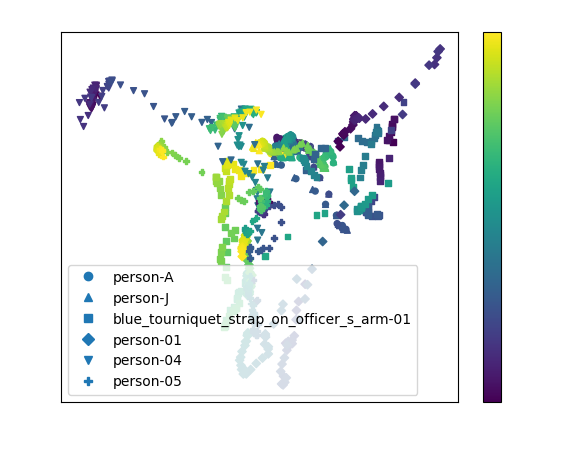

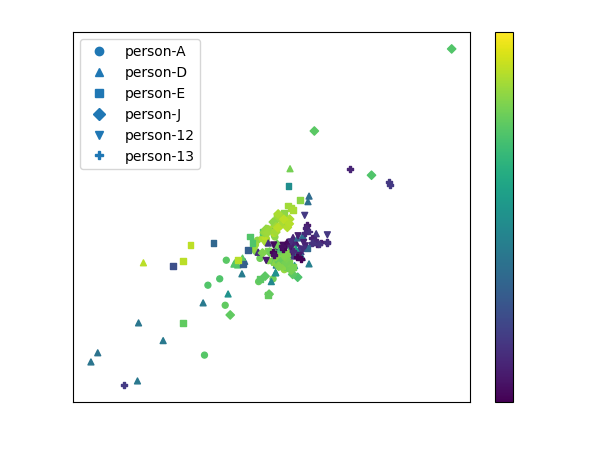

In [24]:
#graph postions 2d - NOT SURE HOW TO USE THIS! POINTLESS FOR THE REPORT!
# One figure per recon -- axes are that recon's own space, so plotting two on one set
# of axes would be meaningless.
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

markers = ["o", "^", "s", "D", "v", "P"]

for job in recon_jobs:
    subj = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    if not subj:
        print(f"{job['beat_key']} {job['kind']}: no subject positions")
        continue

    fig, ax = plt.subplots()
    
    allf    = np.concatenate([np.array(sorted(d)) for d in subj.values()])
    handles = []
    # Letter-named (gem-matched, e.g. person-A) subjects plot before numeric
    # raw ones -- markers is short, so anything past len(markers) gets dropped
    # by zip below, and letter-named subjects matter more for the report.
    ordered_items = sorted(subj.items(), key=lambda kv: kv[0].rsplit('-', 1)[-1].isdigit())
    for (slug, d), mk in zip(ordered_items, markers): 
        frames = np.array(sorted(d))
        pts    = np.array([d[k] for k in frames])
        sc = ax.scatter(pts[:, 0], pts[:, 2], c=frames, cmap="viridis", marker=mk,
                        vmin=allf.min(), vmax=allf.max(), s=18)   # colour = frame number
        handles.append(Line2D([0], [0], marker=mk, ls="",  label=slug))

    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("frame", color="white")
    cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")

    ax.legend(handles=handles)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.set_xlabel("x")
    ax.set_ylabel("z)")
    ax.set_title(f"Subject position, {job['beat_key']} {job['kind']} (color = time)")


In [25]:
if analysis_2d_for_decisions["GPS_signal"] == "yes":
    for job in recon_jobs:
        print(f"--- {job['beat_key']} ---")
        print(job.get("subjects_real_pos", {}).keys())


--- beat-04 EVENT ---
{}
--- beat-06 MAP ---
{}


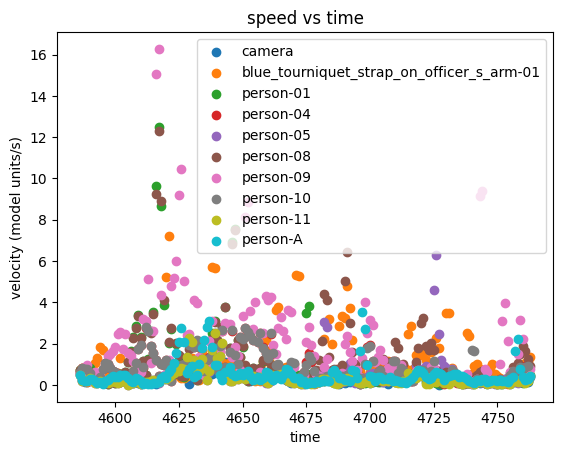

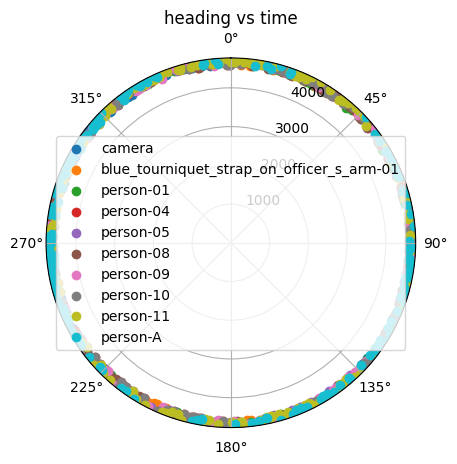

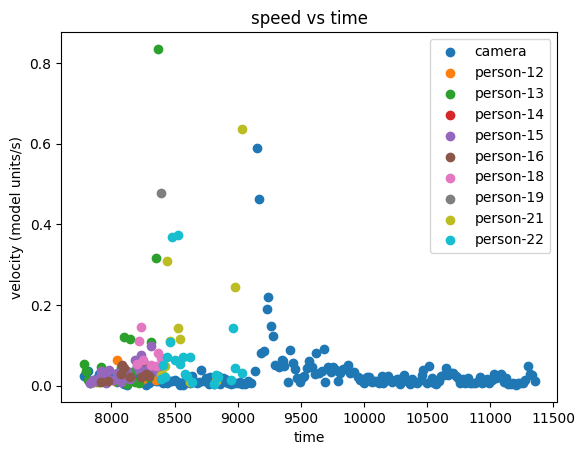

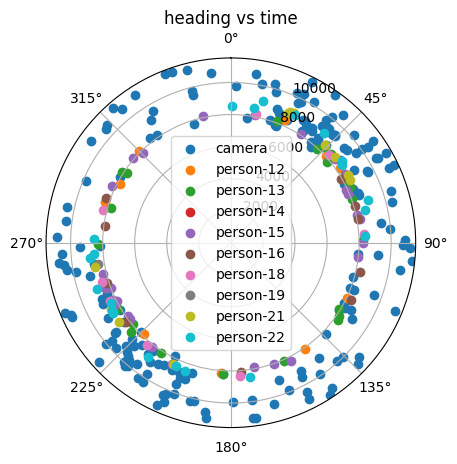

In [26]:
##3D Graphing and analysis METRIC OR NOT - per recon
# Speed/direction and meetings are both distance maths, so they run inside one recon's
# space. A requested pair is only measurable in a recon that actually saw both of them;
# pairs that split across two recons are reported as skipped rather than silently wrong.
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import  meeting_calculator
from render_paper_edit import build_meeting_requests

meeting_pairs = build_meeting_requests(paper_edit_json_path)   # [["person-1","person-2"], ["person-1","camera"]]

for job in recon_jobs:
    subjects = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    job["group_metrics"] = speed_direction(
        {"camera": job["cam_poses_model"], **subjects}, fps)

    meetings = {}
    subjects_distance_to_camera = {}
    for A_dict_entry, B_dict_entry in meeting_pairs:
        B_is_camera = B_dict_entry == "camera"
        if A_dict_entry not in subjects or (not B_is_camera and B_dict_entry not in subjects):
            print(f"{job['beat_key']}: skipping {A_dict_entry} vs {B_dict_entry} "
                  f"-- not both present in this recon")
            continue
        A_real_dict = subjects[A_dict_entry]
        B_real_dict = job["cam_poses_model"] if B_is_camera else subjects[B_dict_entry]

        if B_is_camera:
            meeting_report, distance_series = meeting_calculator(
                A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
                B_is_camera=B_is_camera, return_series=True)
            subjects_distance_to_camera[A_dict_entry] = distance_series
        else:
            meeting_report = meeting_calculator(
                A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
                B_is_camera=B_is_camera)
        meetings[(A_dict_entry, B_dict_entry)] = meeting_report
    job["meetings"] = meetings
    job["subjects_distance_to_camera"] = subjects_distance_to_camera
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print(meetings)

##TEMP TESTS

## this will be deleted

In [27]:
depth_intersection = False
if depth_intersection == True:
    #depth based intersections checker # TEMP
    #mask overlay sequence: person-1 (green) vs sword (magenta)
    from Two2D.W_video_editor import apply_mask_overlay, _load_mask_bool
    from A_Config import assets_dir, source_video_path
    from pathlib import Path
    import cv2
    A_slug, B_slug = "person-1", "the_large_sword-1"
    def _dirs(slug):
        e = analysis_2d_for_decisions[slug]
        return [Path(d) for d in (e.get("masks_dirs") or [e["masks_dir"]])]
    A_dir, B_dir = _dirs(A_slug)[0], _dirs(B_slug)[0]
    #sword is person 5
    B_dir = Path("/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/person-3")   # the sword



    out_dir = assets_dir() / f"contact_check_{A_slug}_vs_{B_slug}"
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = sorted(set(analysis_2d_for_decisions[A_slug]["Subject_frames_present"]) |
                    set(analysis_2d_for_decisions[B_slug]["Subject_frames_present"]))

    cap = cv2.VideoCapture(str(source_video_path()))
    for f in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret:
            continue
        for d, colour in ((A_dir, (0, 200, 0)), (B_dir, (200, 0, 200))):
            m = _load_mask_bool(d, f)
            if m is not None:
                frame = apply_mask_overlay(frame, m, color=colour)
        cv2.imwrite(str(out_dir / f"{f:04d}.png"), frame)
    cap.release()
    print(out_dir, len(frames), "frames")

# TOUCHING TEST
## Needs work  see PHYSICS - NEW FLAGS PLAN MULTI RECON 

In [28]:
# subject touching test
if depth_intersection == True:
    # Manual/WIP cell -- there's no rule yet for which recon a contact test belongs to,
    # so pick the job by hand (see the RECON JOBS cell for what's available).
    from Q_subject_analysis import contact_frames
    job = recon_jobs[0]
    res = contact_frames(job["recon"], A_dir, B_dir)

    r = res[386]          # your contact frame
    plt.plot(list(r["A_profile"]), list(r["A_profile"].values()), "o-", label="A")
    plt.plot(list(r["B_profile"]), list(r["B_profile"].values()), "o-", label="B")
    plt.xlabel("depthels from seam"); plt.ylabel("depth"); plt.legend()
    print(r["depth_gap"], r["fit_resid"], r["contact"])


# PRODUCER 2

In [29]:
#FLAGS dict and 'producer dict
print(flags)
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': True, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': True, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': True, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


In [30]:
print(paper_edit_json_path)

/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_draft.json


In [31]:
#find the cut points
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions, paper_edit_json_path)

off 366.480688
off 501.716521


PosixPath('/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_draft.json')

In [32]:
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502,
                                                                          4503,
                                                                          4504,
                                                                          4505,
                                                                          4506,
                                                                          4507,
                                                                          4508,
                                                                          4509,
                                                                          4510,
                                                                          4511,
                                                                          4512,
                                                                          4513,
                   

In [35]:
#run producer again
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags, paper_edit_json_path)
paper_edit_json_path = run_producer_agent(prompt)

[10:38:10 +  0.00s] run_producer_agent: start
[10:38:10 +  0.00s] thread: start
[10:38:10 +  0.00s] event loop: created
[10:38:10 +  0.00s] query: start
[10:38:17 +  7.03s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=111531 cache_read=0
[10:38:17 +  7.03s] turn 1 content blocks: ['ThinkingBlock']
[10:38:17 +  7.03s] thinking:
I'm checking for overlapping beats and find that beat-08 and beat-09 overlap, so I'll merge them into a single AFTERMATH beat spanning 14520 to 15510. The other beat boundaries look fine, and I'm now folding in supporting facts like the tourniquet detail.
[10:38:42 + 32.95s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=111531 cache_read=0
[10:38:42 + 32.95s] turn 2 content blocks: ['ToolUseBlock']
[10:38:42 + 32.95s] tool call: Write (/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_paper_edit.json)
[10:38:42 + 32.95s] write content:
{
  "case_name": "206_copper_05b",
  "brief": "Make a video summary of this vi

In [36]:
#prevent proucer mistakes
from render_paper_edit import match_revision_beat_ids
match_revision_beat_ids()


{'case_name': '206_copper_05b',
 'brief': 'Make a video summary of this video: officers respond to a shots-fired call, one officer is shot and treated with a tourniquet, and the wounded suspect is given first aid until an ambulance arrives.',
 'beats': [{'archetype': 'ESTABLISHER',
   'order': 1,
   'beat_id': ['beat-01'],
   'segment_type': 'real',
   'duration_seconds': 8,
   'source': 'Bodycam POV, police vehicle interior en route through residential streets (00:00-02:02 window)',
   'start_frame': 3341,
   'end_frame': 3732,
   'lead_in_seconds': None,
   'search_window_start_seconds': 112,
   'search_window_end_seconds': 122,
   'requested_flags': None,
   'quote': None,
   'rationale': 'R6.2 pre-incident state under 10s, no overlap with beat-02 frame range',
   'rejected_alternative': 'Opening at 00:00 — R6.4 two minutes of driving adds no information',
   'flag': None,
   'tracked_subject': None},
  {'archetype': 'EVENT_TRIGGER',
   'order': 2,
   'beat_id': ['beat-02'],
   'seg

In [37]:
#find the cut points again
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions, paper_edit_json_path)

off 366.480688


PosixPath('/workspace/project/Data/206_copper_05b/012_agent_p_output/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_revision.json')

# Rendering

In [38]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'blue_tourniquet_strap_on_officer_s_arm-01': {'Subject_frames_present': [4502, 4503, 4504, 4505, 4506, 4507, 4508, 4509, 4510, 4511, 4512, 4513, 4514, 4515, 4516, 4517, 4518, 4519, 4520, 4521, 4522, 4523, 4524, 4525, 4526, 4527, 4528, 4529, 4530, 4531, 4532, 4533, 4534, 4535, 4536, 4537, 4538, 4539, 4540, 4541, 4542, 4543, 4544, 4545, 4546, 4547, 4548, 4549, 4550, 4551, 4552, 4553, 4554, 4555, 4556, 4557, 4558, 4559, 4560, 4561, 4562, 4563, 4564, 4565, 4566, 4567, 4568, 4569, 4572, 4573, 4574, 4575, 4576, 4577, 4578, 4579, 4580, 4581, 4582, 4583, 4584, 4585, 4586, 4587, 4588, 4589, 4590, 4591, 4592, 4593, 4594, 4595, 4596, 4597, 4598, 4599, 4622, 4623, 4624, 4625, 4626, 4627, 4628, 4629, 4630, 4631, 4632, 4633, 4634, 4635, 4642, 4643, 4644, 4645, 4646, 4647, 4648, 4649, 4650, 4651, 4652, 4653, 4654, 4655, 4656, 4657, 4658, 4659, 4660, 4661, 4662, 4663, 4664, 4665, 4666, 4667, 4668, 4669, 4670, 4671, 4672, 4673, 4674, 4675, 4676, 4677, 4678, 4679, 4680, 4681, 4682, 

## Projection

In [39]:
for job in recon_jobs:
    print(job["beat_key"], job["kind"], job["flag"], job["start_frame"], job["end_frame"])



beat-04 EVENT RECON_3D 4585 4765
beat-06 MAP RECON_CAM_POSES 7762 11389


In [52]:
from Q_subject_analysis import find_mask_centroids_in_model_space, auto_camera_position, look_at_rotation, subject_oriented_box
from P_projection_mapping import solve_auto_camera_extrinsic,  projection_mapping_sequence, mean_camera_extrinsic
from Two2D.B_video_processing import available_frames
from run_models.A_ROBOFLOW_SAM3 import _slugify_subject
#dual setup
# every knob visible and tweakable right here -- raw VGGT-O model units, no metric/GPS needed
margin                  = 0.2   #fraction of to the full-mask-point box, on every side
extra_distance_margin   = 0.0
   # extra pull-back so off-center corners don't clip
conf_percentile         = 30  # drop masked pixels below this depth-confidence percentile
                               # (guards against a misprojected frame blowing the box out --
sr = 3 #splat radius

#load up paper edit beats
_revised_beats_by_key = {
    b["beat_id"][0]: b
    for b in json.loads(paper_edit_path(mode="revision").read_text(encoding="utf-8"))["beats"]
}
#check for projection beats
projection_beats = [b for b in _revised_beats_by_key.values() if b["archetype"] == "PROJECTION"]
if not projection_beats:
    print("no PROJECTION beats in this revision")
else:
#print(_revised_beats_by_key)
#Use this to project every frame in each recon
    for job in jobs_of(kind="EVENT"):
        #print("KEYS",job.keys())
        #-------positions/masks only really need one, but making a mess at first---------------
        all_positions = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
        beat = _revised_beats_by_key.get(job["beat_key"], job["beat"])#open up the paper edit beat

        wanted = {
            entry["gem_person_id"] if isinstance(entry, dict) else _slugify_subject(entry)
            for entry in (beat.get("tracked_subject") or []) #find tracked subjets in the paper edit
        }
        print("Subjects to set camera",wanted)
        subject_positions = {k: v for k, v in all_positions.items() if k in wanted}
        #print("SPs", subject_positions)

        beat_name = job["beat_ids"][0]   # same as W_video_editor's beat_name = beat["beat_id"][0]

        masks_dirs = list(dict.fromkeys(
            d
            for key, entry in (analysis_2d_for_decisions or {}).items()
            if isinstance(entry, dict)
            and job["beat_key"] in (entry.get("beat_ids") or [])
            and (key in wanted or key.rsplit("-", 1)[0] in wanted)
            for d in ([entry["masks_dir"]] if entry.get("masks_dir") else entry.get("masks_dirs") or [])
        ))
        print(masks_dirs)
        extrinsics_np = job["recon"].preds["extrinsic"].cpu().numpy()
        conf_vggt     = job["recon"].preds["depth_conf"].cpu().numpy()
        ct_vggt  = np.percentile(conf_vggt, conf_percentile)

        # Tracking can come back with nothing: no masks_dir for the wanted subject at all,
        # or dirs whose masks are empty on every frame. Collect whatever we do get, per
        # mask dir, and decide afterwards whether there's enough to aim a camera with.
        mask_points_all, weights_all = [], []
        for masks_dir in masks_dirs:
            print(masks_dir)
            subject_cenroids_model, frame_keys, _ ,_ ,weights, mask_points = find_mask_centroids_in_model_space(
            job["recon"],masks_dir, autocam=True,
            conf_thresh=ct_vggt,
            )
            if mask_points is not None and len(mask_points):
                mask_points_all.append(np.asarray(mask_points))
            weights_all.append(np.asarray(weights, dtype=float))
        #final collection -- one point cloud and one per-frame weight vector across all subjects
        mask_points_total = np.concatenate(mask_points_all, axis=0) if mask_points_all else np.empty((0, 3))
        weights_total = np.max(np.stack(weights_all), axis=0) if weights_all else np.zeros(len(extrinsics_np))
        # enough to aim at a subject? need real (non-NaN) points AND at least one frame the
        # subject was actually visible in -- both are what the look-at solve depends on.
        tracked_ok = (
            (~np.isnan(mask_points_total).any(axis=1)).sum() >= 2
            and np.any(weights_total > 0)
        )

        #------get frames-----------
        job["extra_indices"] = available_frames(job["frames_dir"], FRAME_NAME_FMT)
        print(f"{job['beat_key']} {job['kind']}: {len(job['extra_indices'])} frames in recon")
        extra_indices = job["extra_indices"]

        print(extra_indices)

        if tracked_ok:
            # Position from the weighted-average of where the real cameras stood (a robust
            # signal),
            down_refs = extrinsics_np[:, 1, :3]   # each frame's own down axis, model space
            up_model = -(down_refs[weights_total > 0] * weights_total[weights_total > 0, None]).sum(axis=0)
            up_model /= np.linalg.norm(up_model)

            C_avg = auto_camera_position(extrinsics_np, weights_total)
            # One oriented box, used for BOTH the framing solve and the debug draw. Fitting the
            # raw points instead let the box's corners (extreme in all 3 axes at once) stick out
            # past every real point and shoot off-screen.
            obb_corners = subject_oriented_box(mask_points_total, margin = margin,percentile=95)
            box_center = obb_corners.mean(axis=0)
            R_auto_c2w = look_at_rotation(C_avg, box_center, up_model)

            new_view = solve_auto_camera_extrinsic(
                obb_corners, box_center, R_auto_c2w,
                job["recon"].preds["intrinsic"][0].cpu().numpy(),
                job["recon"].preds["depth"].shape[1:],
                extra_distance_margin=extra_distance_margin,
                dtype=job["recon"].preds["extrinsic"].dtype,
            )

            print("R_auto orthonormal check:", np.allclose(R_auto_c2w @ R_auto_c2w.T, np.eye(3), atol=1e-4), "det:", np.linalg.det(R_auto_c2w))
            print("C_avg (model units):", C_avg, "box_center:", box_center)
            print("weights: min/max/mean/#nonzero:", weights_total.min(), weights_total.max(), weights_total.mean(), (weights_total > 0).sum())
        else:
            # FALLBACK -- tracking gave us nothing to aim at, so frame on the mean of the
            # real cameras instead of on the subject. The shot still gets made; it's just
            # "where the shoot was pointed", not "where the subject was".
            print(f"{job['beat_key']}: no usable subject masks "
                  f"({len(masks_dirs)} mask dir(s), {len(mask_points_total)} points) "
                  "-- falling back to the mean camera pose")
            new_view = mean_camera_extrinsic(
                extrinsics_np,
                pull_back=extra_distance_margin,
                dtype=job["recon"].preds["extrinsic"].dtype,
            )
        #---------------------------------------------------------------------------------------------

        #new_view = recon.preds["extrinsic"][-1]
        _ = projection_mapping_sequence(
            recon=job["recon"],
            extra_indices=extra_indices,  # one output frame per source frame, default naming
            #extra_indices= [282],  # one output frame per source frame, default naming
            new_view=new_view,
            confidence_threshold=ct_vggt,
            #masks_dir = masks_dir,
            use_lowres_images=False,
            splat_radius = sr,
            frame_rate = fps,
            out_dir_name= f"projection_frames_{job['beat_key']}"


        )
        #---------------------------------------------------------------------------------------------------------------------------------------


Subjects to set camera {'person-A'}
['/workspace/project/Data/206_copper_05b/015_SAM3_masks/Pipe_eval_01/person-02', '/workspace/project/Data/206_copper_05b/015_SAM3_masks/Pipe_eval_01/person-66']
/workspace/project/Data/206_copper_05b/015_SAM3_masks/Pipe_eval_01/person-02


/workspace/project/src/Q_subject_analysis.py:343: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:347: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:351: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R


393.8913337296263


/workspace/project/src/Q_subject_analysis.py:364: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


/workspace/project/Data/206_copper_05b/015_SAM3_masks/Pipe_eval_01/person-66
nan
beat-04 EVENT: 178 frames in recon
[4585, 4586, 4587, 4588, 4589, 4590, 4591, 4592, 4593, 4594, 4595, 4596, 4597, 4598, 4599, 4600, 4601, 4602, 4603, 4604, 4605, 4606, 4607, 4608, 4609, 4610, 4611, 4612, 4613, 4614, 4615, 4616, 4617, 4618, 4619, 4620, 4621, 4622, 4623, 4624, 4625, 4626, 4627, 4628, 4629, 4630, 4631, 4632, 4633, 4634, 4635, 4636, 4637, 4638, 4639, 4640, 4641, 4642, 4643, 4645, 4646, 4647, 4648, 4649, 4650, 4651, 4652, 4653, 4654, 4655, 4656, 4657, 4658, 4659, 4660, 4661, 4662, 4663, 4664, 4665, 4666, 4667, 4668, 4669, 4670, 4671, 4672, 4673, 4674, 4675, 4676, 4677, 4678, 4679, 4680, 4681, 4682, 4683, 4684, 4685, 4686, 4687, 4688, 4689, 4690, 4691, 4692, 4693, 4694, 4695, 4696, 4697, 4698, 4699, 4700, 4701, 4702, 4703, 4704, 4705, 4707, 4708, 4709, 4710, 4711, 4712, 4713, 4714, 4715, 4716, 4717, 4718, 4719, 4720, 4721, 4722, 4723, 4724, 4725, 4726, 4727, 4728, 4729, 4730, 4731, 4732, 4733, 4

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

## Mapping

In [43]:
#make animated map -- one map per GOOGLE_MAP beat. Each writes its own image sequence
# to assets/map_frames_<beat_key> (the standard hand-off to the editor); gif/mp4 are
# optional extra exports of the same frames. Duration comes from the beat we pass in,
# so two MAP beats get two different-length animations instead of sharing one.
flags["GOOGLE_MAP"] = True
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator
    from run_models.A_ROBOFLOW_SAM3 import _slugify_subject
    from render_paper_edit import paper_edit_path

    _default_palette = ["#e74c3c", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22"]

    # Revision pass can still edit tracked_subject after recon_jobs was built (cell 28
    # read the draft) -- re-read the revised paper edit here, same fix as the
    # BEV_trace_overlay cell, so subjects_latlon only shows what THIS beat actually asked for.
    _revised_beats_by_key = {
        b["beat_id"][0]: b
        for b in json.loads(paper_edit_path(mode="revision").read_text(encoding="utf-8"))["beats"]
    }

    for job in jobs_of(archetype="MAP", flag="GOOGLE_MAP"):
        beat = _revised_beats_by_key.get(job["beat_key"], job["beat"])
        wanted = {
            entry["gem_person_id"] if isinstance(entry, dict) else _slugify_subject(entry)
            for entry in (beat.get("tracked_subject") or [])
        }
        subject_traces = [
            {"coords": latlons, "trail_color": _default_palette[i % len(_default_palette)]}
            for i, (slug, latlons) in enumerate(job.get("subjects_latlon", {}).items())
            if slug in wanted
        ]
        Rendering.R_map_animator.main(
            traces = [
                {"coords": job["cam_latlons"], "trail_color": "#3498db"},     #cameras
                *subject_traces,
            ],
            api_key = api_key,
            beat    = beat,
            gif = True,
            mp4 = None,
        )
else:
     print("Cell disabled")


In [45]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)

In [46]:
#BEV SETUP - the frames each recon actually holds, per job
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles

from Two2D.B_video_processing import available_frames

#Use this to project every frame in each recon
for job in recon_jobs:
    job["extra_indices"] = available_frames(job["frames_dir"], FRAME_NAME_FMT)
    print(f"{job['beat_key']} {job['kind']}: {len(job['extra_indices'])} frames in recon")


beat-04 EVENT: 178 frames in recon
beat-06 MAP: 191 frames in recon


In [47]:
#BEV HI RES - one BEV still per BEV_MAP beat
#BEV projection mapping of subject to a selected view
# BEV_tile_render_PM's default out_path is asset_name-based (one file for the whole
# case), so pass a beat-keyed path in. That also skips its own add_to_asset_list, so
# the beat-keyed asset row is logged here instead.
from A_Config import assets_dir, asset_name, to_report_path
from C_CSV_report import add_to_asset_list

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    out_path = assets_dir() / f"{asset_name()}_BEV_tile_render_PM_{job['beat_key']}.png"
    BEV, job["new_view"], job["ortho_params"], job["BEV_path"] = BEV_tile_render_PM(
        job["recon"],
        job["extra_indices"],
        masks_dir = None,
        splat_radius = 1,
        confidence_threshold=np.percentile(conf, 60),
        margin_frac = 0.05,
        out_path = out_path,
    )
    add_to_asset_list({f"BEV_tile_render_PM_{job['beat_key']}": to_report_path(job["BEV_path"])})
    print(f"{job['beat_key']}: {job['BEV_path']}")


min depth tensor(0.0044, device='cuda:0')
torch.Size([20184233, 3])
mins, maxes and ranges -0.5546475902199746 0.9459658816456795 1.500613471865654 -1.0325951635837556 1.1980716049671174 2.230666768550873
scale - original 2455.581519290352
beat-06: /workspace/project/Data/206_copper_05b/090_assets/Pipe_eval_01/206_copper_05b_Pipe_eval_01_BEV_tile_render_PM_beat-06.png


In [48]:
subject_positions = job.get("subjects_positions") or {},
print(job['beat_key'])
pprint(subject_positions)

beat-06
({'person-12': {7813: array([-0.00690133,  0.00400202,  0.05486952]),
                7830: array([-0.00783258,  0.00833412,  0.06340634]),
                7876: array([-0.02452344, -0.00572554,  0.06418692]),
                8028: array([-0.0378531 , -0.04004583,  0.03203672]),
                8047: array([0.02090631, 0.02422985, 0.04261019]),
                8073: array([0.01869611, 0.01758774, 0.0831989 ]),
                8081: array([0.00599314, 0.00841631, 0.05752238]),
                8096: array([0.02849336, 0.04696421, 0.06915555]),
                8123: array([0.03154582, 0.0476106 , 0.06239878]),
                8237: array([0.02747844, 0.01477509, 0.05574958]),
                8247: array([ 0.00625547, -0.00564011,  0.07054525]),
                8351: array([0.07063019, 0.04645365, 0.08517739]),
                8370: array([ 0.03045728, -0.00078209,  0.12550367])},
  'person-13': {7769: array([0.02327798, 0.00974469, 0.03476111]),
                7781: array([1.7426

In [49]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#One animation per BEV_MAP beat, each over its own BEV still. n_frames comes from the beat
#we pass in (duration_seconds * fps), and frames land in bev_trace_frames_<beat_key>.
from P_trace_overlayer import BEV_trace_overlay
from run_models.A_ROBOFLOW_SAM3 import _slugify_subject
from render_paper_edit import paper_edit_path

#load up papter edit beats
_revised_beats_by_key = {
    b["beat_id"][0]: b
    for b in json.loads(paper_edit_path(mode="revision").read_text(encoding="utf-8"))["beats"]
}

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    all_positions = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    beat = _revised_beats_by_key.get(job["beat_key"], job["beat"])#open up the paper edit beat

    # Only the subjects THIS beat's own (revised) tracked_subject named in the
    # paper edit -- not every track the recon happens to have positions for
    # (generic person-09..19 etc. that were never asked for on this beat).
    wanted = {
        entry["gem_person_id"] if isinstance(entry, dict) else _slugify_subject(entry)
        for entry in (beat.get("tracked_subject") or []) #find tracked subjets in the paper edit
    }
    subject_positions = {k: v for k, v in all_positions.items() if k in wanted}
    BEV_trace_overlay(
        job["recon"],
        job["extra_indices"],
        job["new_view"],
        job["ortho_params"],
        subject_positions = subject_positions,
        bev_png_path      = job["BEV_path"],
        beat              = beat,
    )


frame 0000 t_frac=0.0000 [camera] virtual_frame=7769.0 pos_px=(268.5, 580.1)
frame 0001 t_frac=0.0028 [camera] virtual_frame=7779.1 pos_px=(268.7, 576.6)
frame 0002 t_frac=0.0056 [camera] virtual_frame=7789.1 pos_px=(267.3, 573.2)
frame 0003 t_frac=0.0084 [camera] virtual_frame=7799.2 pos_px=(265.6, 569.7)
frame 0004 t_frac=0.0112 [camera] virtual_frame=7809.3 pos_px=(271.7, 562.7)
frame 0005 t_frac=0.0140 [camera] virtual_frame=7819.3 pos_px=(275.3, 558.4)
frame 0006 t_frac=0.0168 [camera] virtual_frame=7829.4 pos_px=(275.6, 556.3)
frame 0007 t_frac=0.0196 [camera] virtual_frame=7839.4 pos_px=(275.7, 555.9)
frame 0008 t_frac=0.0223 [camera] virtual_frame=7849.5 pos_px=(275.7, 555.7)
frame 0009 t_frac=0.0251 [camera] virtual_frame=7859.6 pos_px=(275.8, 555.2)
frame 0009 t_frac=0.0251 [person-D] virtual_frame=7859.6 pos_px=(267.8, 547.6)
frame 0010 t_frac=0.0279 [camera] virtual_frame=7869.6 pos_px=(276.2, 554.5)
frame 0010 t_frac=0.0279 [person-D] virtual_frame=7869.6 pos_px=(268.1, 54

In [50]:
import torch
print(torch.is_autocast_enabled())


False


In [53]:
#Make the edited multimedia movie

import Two2D.W_video_editor
 
Two2D.W_video_editor.assemble_paper_edit(video_path,analysis_2d_for_decisions, recon_jobs=recon_jobs)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-03


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-07


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

/workspace/project/Data/206_copper_05b/090_assets/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_rough_cut.mp4


[aac @ 0x5647e0e90fc0] Qavg: 12485.143


PosixPath('/workspace/project/Data/206_copper_05b/090_assets/Pipe_eval_01/206_copper_05b_Pipe_eval_01_1_rough_cut.mp4')

In [ ]:
print(PASS)

In [56]:
from V_text_summary import gemini_final_report, gemini_cache_video
vid_path = assets_dir() / f"{asset_name()}_{PASS}_rough_cut.mp4"
cache =  gemini_cache_video(vid_path, assets_dir(), ttl="6000s")
gemini_final_report()

On June 5, 2022, at approximately 2:02 PM, body camera footage captured officers responding to a shooting incident in a residential neighborhood in Chicago, Illinois.

The first subject, highlighted with a green mask, is an injured police officer kneeling on the pavement who is tracked as person-J from 13:11:18 to 13:14:54. The officer is positioned near a discarded handgun on the street while another officer works to apply a black tourniquet strap to his bleeding arm. Over the course of this encounter, the officer moves a net distance of approximately 0.125 model units in a North-Northwest direction at a heading of 348.4 degrees. 

The second subject, also highlighted in green, is an injured individual lying on the sidewalk receiving medical attention from officers and paramedics. This individual is tracked as person-D from 13:13:09 to 13:14:54, traveling a net distance of 0.475 model units in a West-Southwest direction at a heading of 261.1 degrees. They are also tracked as person-E 

In [ ]:

timer_end()


In [ ]:
# Cell — Populate PowerPoint from CSV
import importlib

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))